# Phase 4: Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) is the process of understanding the dataset through statistical summaries and visualizations.

The main goals are:

- Understand the distribution of each feature
- Identify relationships between variables
- Detect patterns related to customer churn
- Generate business insights
- Prepare for feature engineering and machine learning

# Step 1: Import Libraries

In [5]:
import pandas as pd
import numpy as np

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# Step 2: Load the Cleaned Dataset

In [7]:
df = pd.read_csv("../data/processed/telco_clean.csv")

# Step 3: Basic Information

In [8]:
df.shape

(7043, 41)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             7043 non-null   object 
 1   Age                                7043 non-null   int64  
 2   Under 30                           7043 non-null   object 
 3   Senior Citizen                     7043 non-null   object 
 4   Married                            7043 non-null   object 
 5   Dependents                         7043 non-null   object 
 6   Number of Dependents               7043 non-null   int64  
 7   City                               7043 non-null   object 
 8   Zip Code                           7043 non-null   int64  
 9   Latitude                           7043 non-null   float64
 10  Longitude                          7043 non-null   float64
 11  Population                         7043 non-null   int64

In [10]:
df.head()

,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,City,Zip Code,Latitude,...,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Label
0,Male,78,No,Yes,No,No,0,Los Angeles,90022,34.023810,...,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Yes
1,Female,74,No,Yes,Yes,Yes,1,Los Angeles,90063,34.044271,...,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Yes
2,Male,71,No,Yes,No,Yes,3,Los Angeles,90065,34.108833,...,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Yes
3,Female,78,No,Yes,Yes,Yes,1,Inglewood,90303,33.936291,...,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Yes
4,Female,80,No,Yes,Yes,Yes,1,Whittier,90602,33.972119,...,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Yes


PART 1 — UNIVARIATE ANALYSIS
(Understanding one variable at a time)

In [11]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

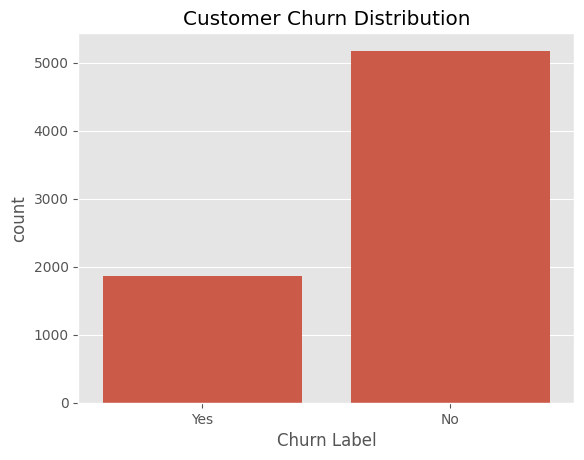

In [12]:
sns.countplot(x="Churn Label", data=df)

plt.title("Customer Churn Distribution")

plt.show()

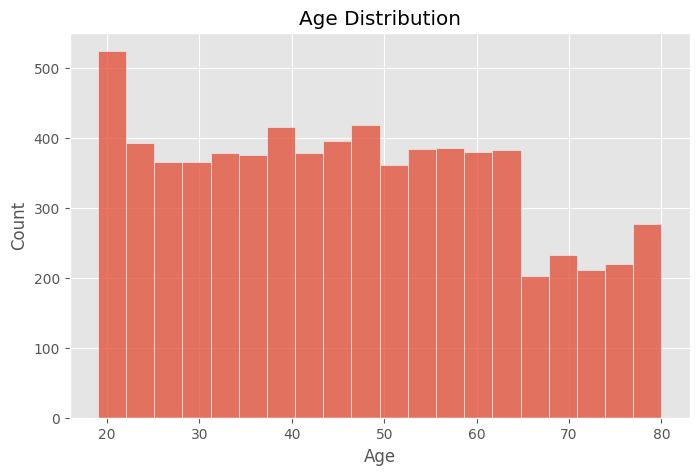

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20)

plt.title("Age Distribution")

plt.show()

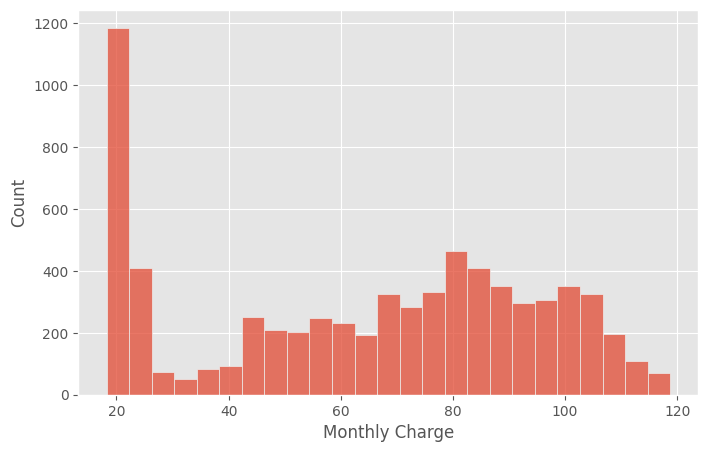

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["Monthly Charge"], bins=25)

plt.show()

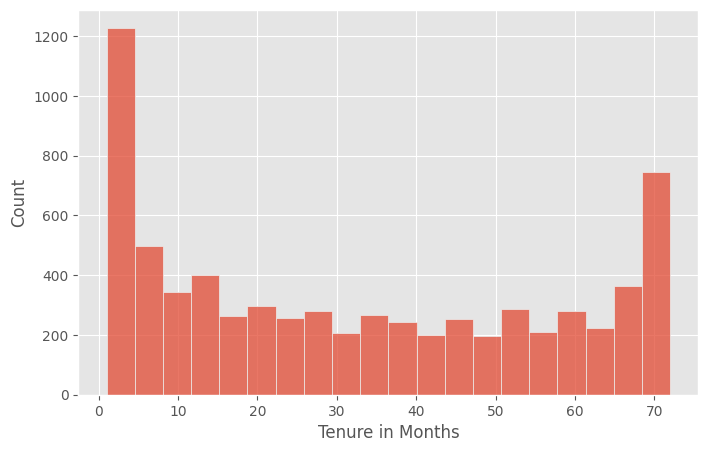

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["Tenure in Months"], bins=20)

plt.show()

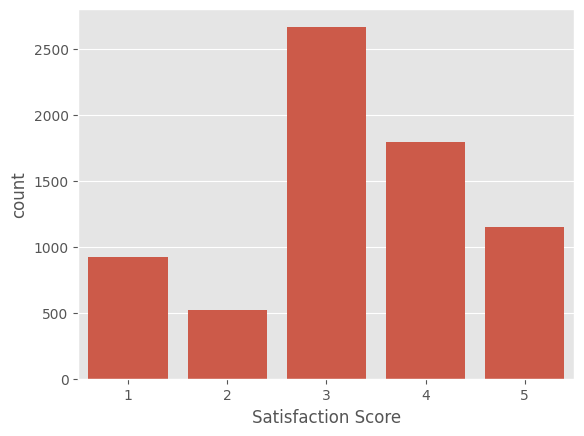

In [16]:
sns.countplot(x="Satisfaction Score", data=df)

plt.show()

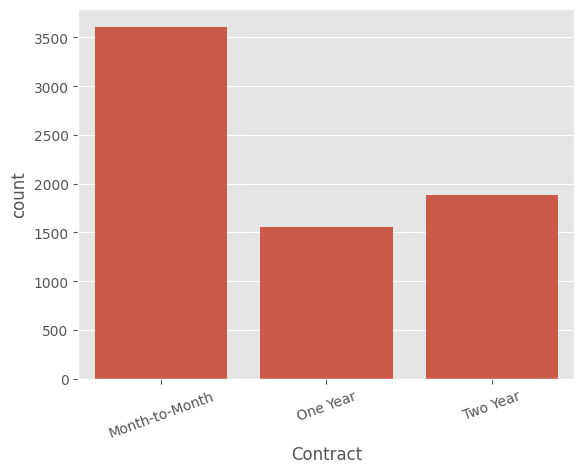

In [17]:
sns.countplot(x="Contract", data=df)

plt.xticks(rotation=20)

plt.show()

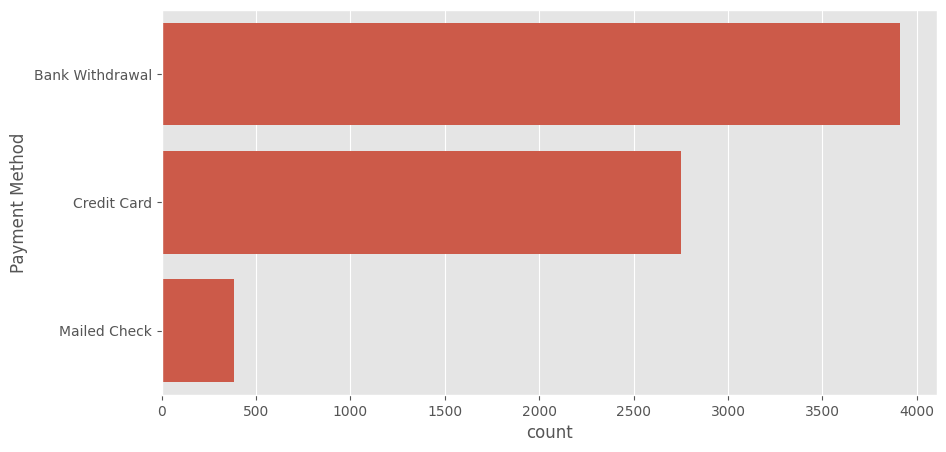

In [18]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="Payment Method",
    data=df
)

plt.show()

PART 2 — BIVARIATE ANALYSIS
(Relationship with Churn)

In [19]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"]
)

Churn Label,No,Yes
Contract,,
Month-to-Month,1955,1655
One Year,1384,166
Two Year,1835,48


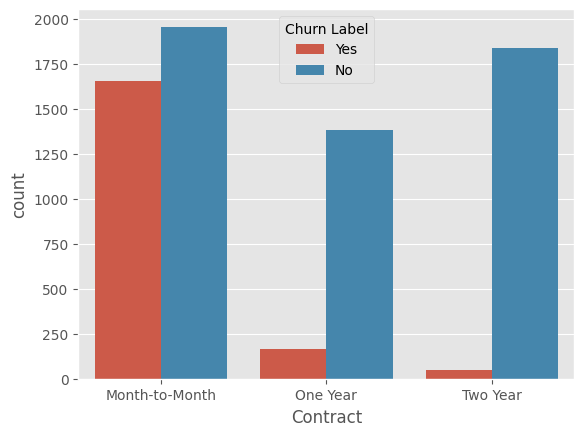

In [20]:
sns.countplot(
    x="Contract",
    hue="Churn Label",
    data=df
)

plt.show()

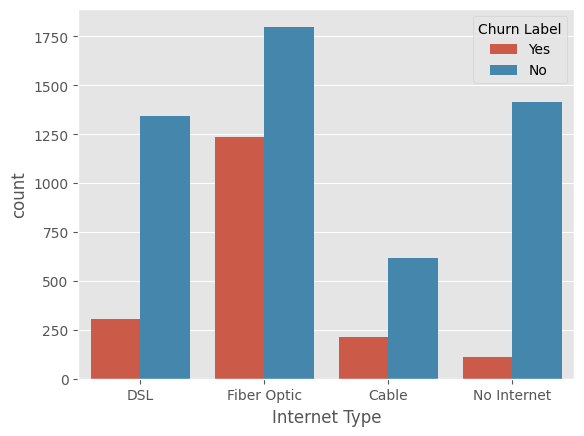

In [21]:
sns.countplot(
    x="Internet Type",
    hue="Churn Label",
    data=df
)

plt.show()

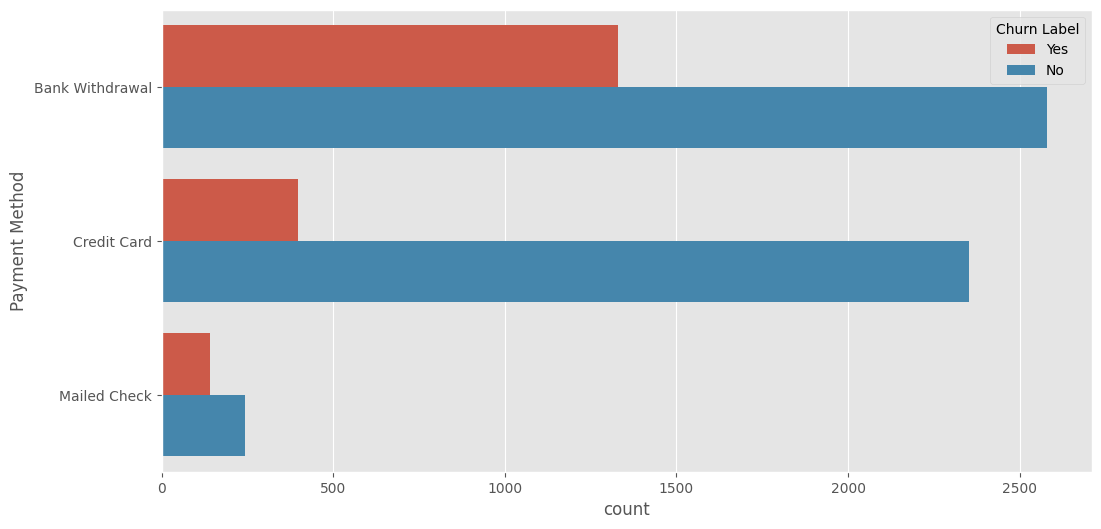

In [22]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="Payment Method",
    hue="Churn Label",
    data=df
)

plt.show()

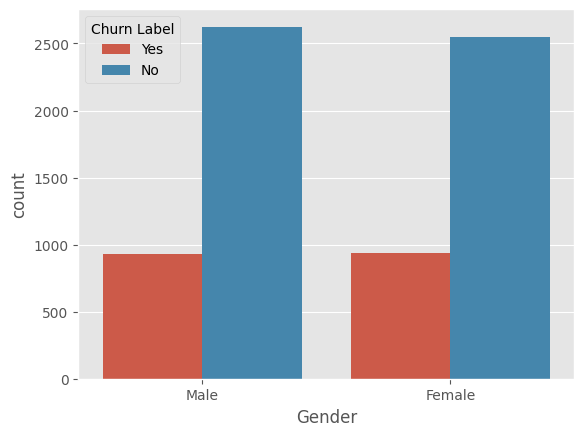

In [23]:
sns.countplot(
    x="Gender",
    hue="Churn Label",
    data=df
)

plt.show()

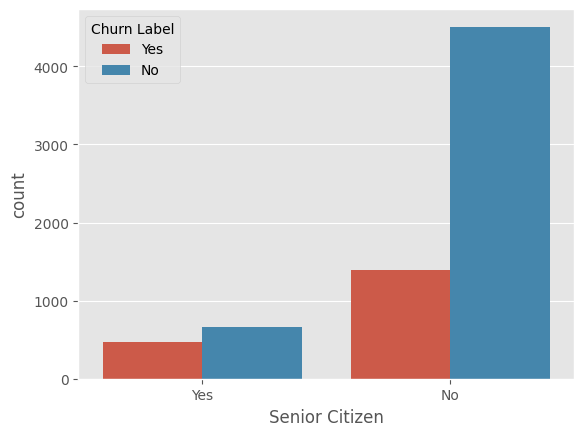

In [24]:
sns.countplot(
    x="Senior Citizen",
    hue="Churn Label",
    data=df
)

plt.show()

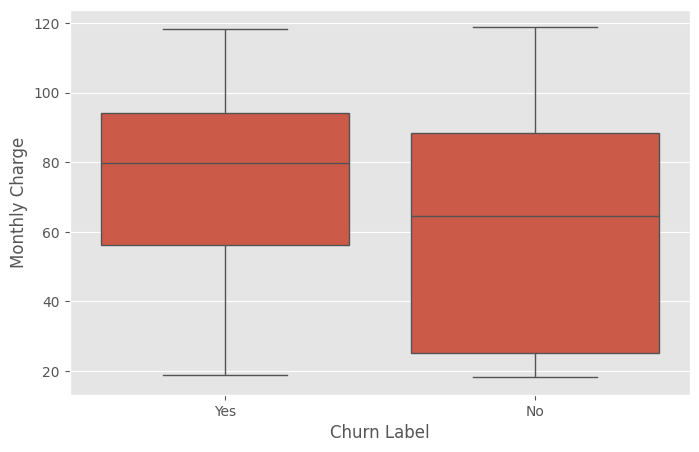

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn Label",
    y="Monthly Charge",
    data=df
)

plt.show()

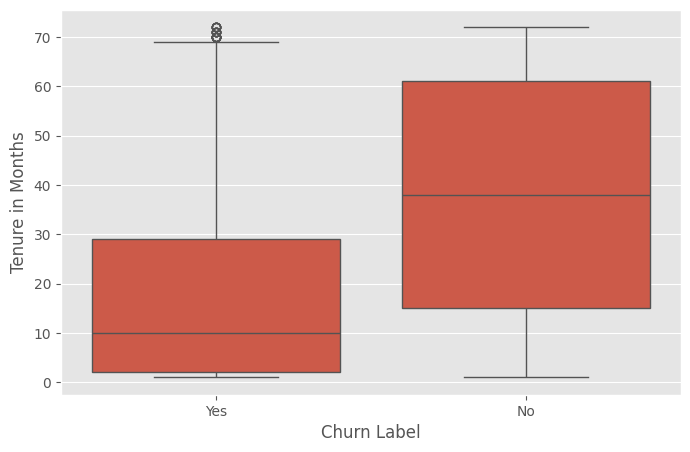

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn Label",
    y="Tenure in Months",
    data=df
)

plt.show()

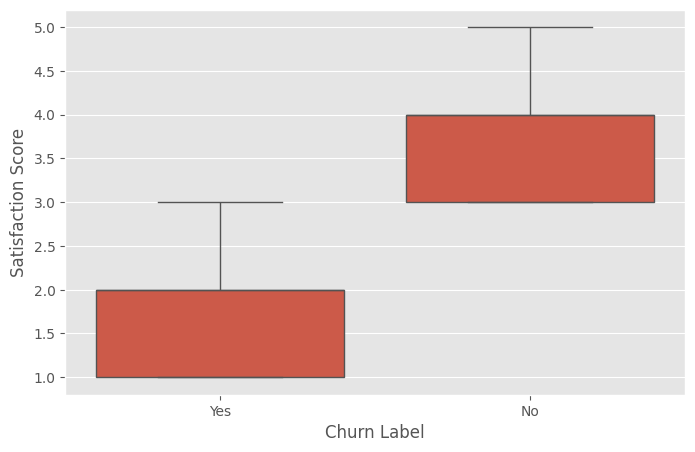

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn Label",
    y="Satisfaction Score",
    data=df
)

plt.show()

PART 3 — CORRELATION

In [28]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

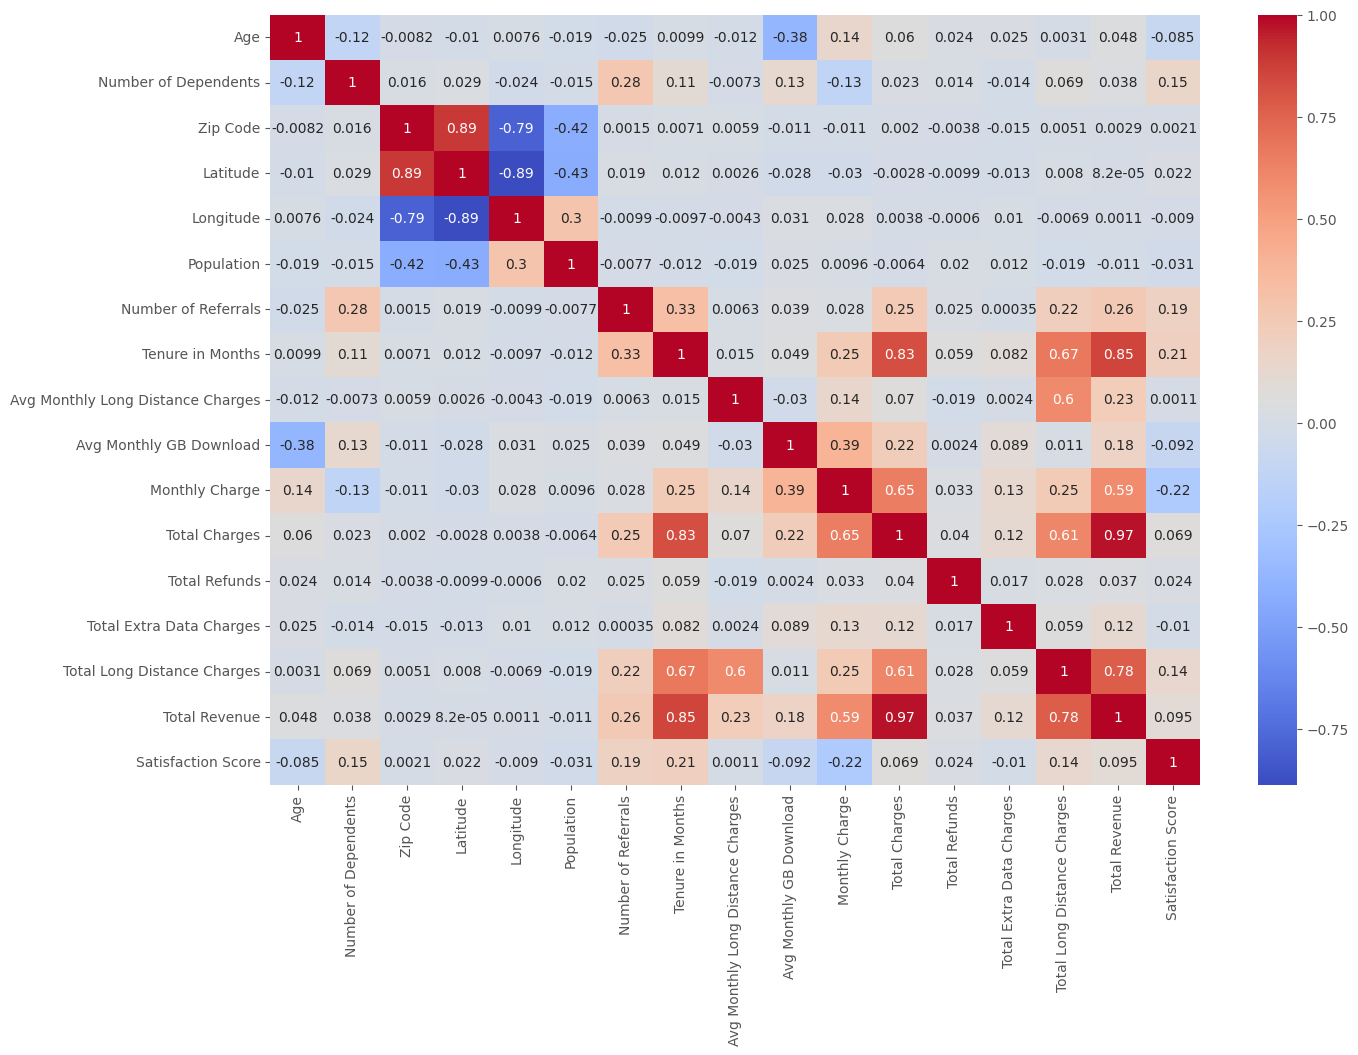

In [29]:
plt.figure(figsize=(15,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

PART 4 — BUSINESS INSIGHTS
Instead of just plotting charts, answer these questions.

# Key Findings

1. The dataset is imbalanced, with approximately 74% of customers staying and 26% churning.
2. Customers with month-to-month contracts exhibit the highest churn rate.
3. Higher monthly charges are associated with a greater likelihood of churn.
4. Customers with shorter tenure tend to churn more frequently.
5. Lower satisfaction scores are strongly associated with churn.
6. Fiber optic customers show higher churn compared to other internet types.
7. Senior citizens appear to have a higher churn rate than non-senior customers.
8. Retention efforts should focus on newer customers with month-to-month contracts, higher monthly charges, and lower satisfaction scores.

In [30]:
pd.crosstab(df["Contract"], df["Churn Label"])

Churn Label,No,Yes
Contract,,
Month-to-Month,1955,1655
One Year,1384,166
Two Year,1835,48


In [31]:
pd.crosstab(df["Internet Type"], df["Churn Label"])

Churn Label,No,Yes
Internet Type,,
Cable,617,213
DSL,1345,307
Fiber Optic,1799,1236
No Internet,1413,113


In [32]:
pd.crosstab(df["Payment Method"], df["Churn Label"])

Churn Label,No,Yes
Payment Method,,
Bank Withdrawal,2580,1329
Credit Card,2351,398
Mailed Check,243,142
